# Tune reduction parameters

Use this notebook to **load real data, review individual frames, and dial in the
reduction parameters** interactively. When you are happy with them, it saves the
config to a JSON file and prints the exact `pxr-reduce` command to run on the full
dataset:

```bash
pxr-reduce run "your/data" --config tuned_config.json
```

Workflow: peek the dataset → pick a small tuning subset (fast iteration) → edit
the config and re-run the review cell until the ROI/mask/dark boxes look right →
save the config → run the CLI.

## 1. Setup

In [1]:
%matplotlib inline
import logging
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

from pxr_reduce import PXRLoader, ReductionConfig
from pxr_reduce.viewer import frame_figure

# Show pxr-reduce progress messages in the notebook (tqdm bars appear on their
# own), while keeping noisy third-party libraries quiet.
logging.basicConfig(level=logging.WARNING, format="%(message)s")
logging.getLogger("pxr_reduce").setLevel(logging.INFO)

## 2. Point at your data

In [3]:
data_folder = Path(r"D:/ALS/2020 Nov/MF114A/spol/250eV")  # <- EDIT THIS
data_folder = Path(r"W:\WenkaiZhong\2026 07 01\CCD Scan 89854\Axis Photonique")
data_folder = Path(r"C:\Users\TJFerron\Documents\Temp_Data\Wenkai_Z\XRR_TEST\B1A1_XRR_P100_17344 Images")
files = sorted(data_folder.glob("*.fits"))
print(f"{len(files)} FITS files in {data_folder}")
assert files, "No .fits files found - check the path."

1521 FITS files in C:\Users\TJFerron\Documents\Temp_Data\Wenkai_Z\XRR_TEST\B1A1_XRR_P100_17344 Images


In [4]:
#files = files[:300]

## 3. Starting parameters

Edit this cell as you iterate. The most common knobs are shown; see the
Configuration reference for the rest. Re-run this cell and the review cell below
after each change.

In [5]:
config = ReductionConfig(
    detector="cmos_11012",
    # --- beam integration ROI ---
    roi_height=40,      # ROI height [px]
    roi_width=40,       # ROI width  [px]
    # roi_from_beam_fit=True, roi_n_sigma=3.0,   # or size the ROI from the direct beam
    # --- image cleanup ---
    trim_x=20,          # edge pixels trimmed (vertical)
    trim_y=20,          # edge pixels trimmed (horizontal)
    mask_threshold=100,  # counts marking the beam region for the mask
    drift_distance=45,  # allowed beam drift [px]
    filter_size = 5,      # median filter size [px]
    dezinger_threshold = 10.0,  # multiple of local median to replace hot pixels

    # --- dark (background) region ---
    dark_pix_offset=50, # gap between beam ROI and dark ROI [px]
    darkside="LHS",     # side to sample the dark region
)
config

ReductionConfig(detector='cmos_11012', exposure_offset=0.00389278, energy_resolution=20.0, energy_offset=0.0, sam_th_offset=None, sam_th_correction=True, roi_height=40, roi_width=40, trim_x=20, trim_y=20, filter_size=5, dezinger=True, dezinger_threshold=10.0, mask_threshold=100, mask_max_frames=200, drift_distance=45, dark_pix_offset=50, darkside='LHS', saturate_threshold=2.0, beam_snr_min=3.0, track_smoothing=True, track_poly_order=3, centroid_radius=8, roi_from_beam_fit=False, roi_n_sigma=3.0, roi_fit_window=50, stitch_cutoff=1.003, stitch_mark_tol=1e-05, new_scan_marker=15.0, drop_failed_stitch=True)

In [6]:
full = PXRLoader(files, config)
full.process()
r = full.reduce(apply_scale=True)
print(r.groupby("energy").size())

Loading 1521 file(s) — reading headers...


Loading FITS headers:   0%|          | 0/1521 [00:00<?, ?file/s]

sam_th offset not given; assuming theta-2theta geometry -> offset determined to be -0.2775 deg
Loaded 1521 frames for sample 'B1A1_XRR_P100_17344_'
Building integration mask from 191 frame(s)


Building mask:   0%|          | 0/191 [00:00<?, ?it/s]

Tracking beam (search radius 45 px) and integrating 1521 frame(s)...


Scan 0:   0%|          | 0/540 [00:00<?, ?it/s]

KeyboardInterrupt: 

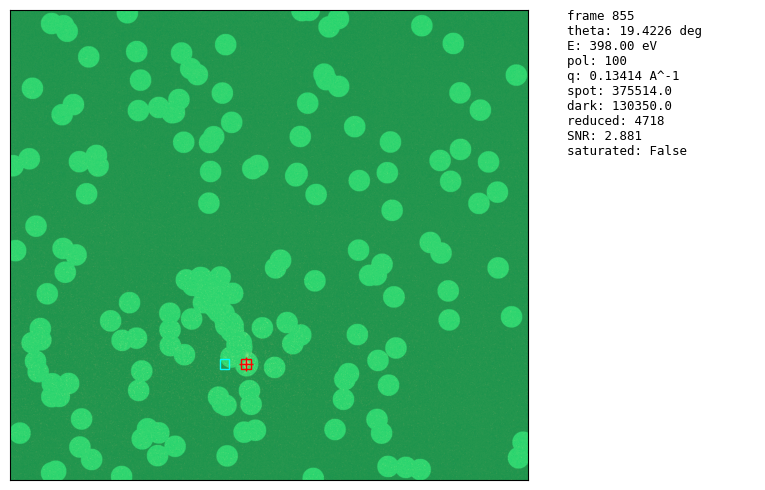

In [63]:
frame_figure(full, 855)

In [5]:
import inspect
import numpy as np
from pxr_reduce import reduction
from pxr_reduce.core import PXRLoader

# (1) Confirm which code is actually loaded
print("CODE CHECK — _anchor params:", list(inspect.signature(PXRLoader._anchor).parameters))
#   latest (reverted) = ['self','fits_index','arow','acol','anchor_mask']
#   stale (buggy)     = ['self','fits_index']

# (2) Per-scan sam_z pattern + where the "direct-beam / move" is detected
d = full.data
for s, g in d.groupby("scan"):
    g = g.reset_index(drop=True)
    mv = g.index[g["sam_z"].diff().abs() > 0.1]
    mp = int(mv[0]) if len(mv) else None
    print(f"scan {s}: n={len(g)}  first_move_idx={mp}  "
          f"sam_z[0]={g['sam_z'].iloc[0]:.2f}  sam_z_uniq={np.round(g['sam_z'].unique(),2)[:8]}")

# (3) Which finalize filter is dropping points
df = reduction._apply_per_scan(d, lambda x: reduction.normalize_scan(x, full.config))
df = reduction._apply_per_scan(df, lambda x: reduction.mark_stitch_points(x, full.config))
df = reduction._apply_per_scan(df, lambda x: reduction.compute_scale_factors(x, full.config))
df = reduction.apply_scaling(df, full.config)
print("total frames      :", len(df))
print("  dropped i0_mask :", int((df['i0_mask'] >= 1).sum()))
print("  dropped saturated:", int(df['is_saturated'].astype(bool).sum()))
print("  dropped R<=0    :", int((df['R'] <= 0).sum()))
print("  dropped failed_stitch:", int((df['failed_stitch_mask'] >= 1).sum()))

CODE CHECK — _anchor params: ['self', 'fits_index', 'arow', 'acol', 'anchor_mask']
scan 0: n=549  first_move_idx=10  sam_z[0]=-3.00  sam_z_uniq=[-3.   -0.75]
scan 1: n=572  first_move_idx=10  sam_z[0]=-3.00  sam_z_uniq=[-3.   -0.75]
scan 2: n=574  first_move_idx=10  sam_z[0]=-3.00  sam_z_uniq=[-3.   -0.75]
scan 3: n=574  first_move_idx=10  sam_z[0]=-3.00  sam_z_uniq=[-3.   -0.75]
total frames      : 2269
  dropped i0_mask : 40
  dropped saturated: 0
  dropped R<=0    : 2214
  dropped failed_stitch: 0


In [15]:
for s, g in full.data.groupby("scan"):
    g = g.reset_index(drop=True)
    mv = g.index[g["sam_z"].diff().abs() > 0.1]
    mp = int(mv[0]) if len(mv) else 0
    dfr = g.iloc[:mp]
    print(f"scan {s}: n_direct={mp}  i0(mean counts_refl)={dfr['counts_refl'].mean():.4g}")
    print("  spot :", dfr["counts_spot"].round(1).tolist())
    print("  dark :", dfr["counts_dark"].round(1).tolist())
    print("  refl :", dfr["counts_refl"].round(3).tolist())
    print("  beam :", dfr["beam_spot"].tolist())

scan 0: n_direct=10  i0(mean counts_refl)=-1.186e+05
  spot : [124486.0, 122124.0, 122119.0, 123096.0, 122281.0, 121647.0, 121918.0, 122430.0, 122069.0, 122069.0]
  dark : [752610.0, 718327.0, 492345.0, 473413.0, 464702.0, 438551.0, 366227.0, 353613.0, 334295.0, 326436.0]
  refl : [-213039.508, -202267.521, -125621.075, -118873.748, -116200.233, -107397.366, -82812.527, -78371.854, -71948.763, -69296.872]
  beam : [(243, 408), (244, 408), (244, 407), (244, 407), (245, 407), (245, 407), (245, 406), (245, 406), (246, 406), (246, 406)]
scan 1: n_direct=10  i0(mean counts_refl)=-1.97e+04
  spot : [123961.0, 121993.0, 121928.0, 121361.0, 121305.0, 121549.0, 122217.0, 121637.0, 121520.0, 121823.0]
  dark : [263071.0, 247650.0, 251190.0, 210805.0, 206292.0, 204094.0, 181318.0, 175526.0, 178462.0, 177506.0]
  refl : [-31279.405, -28260.225, -29020.375, -20083.126, -19083.677, -18538.804, -13274.278, -12103.738, -12792.849, -12513.659]
  beam : [(245, 407), (245, 407), (245, 407), (246, 406), (

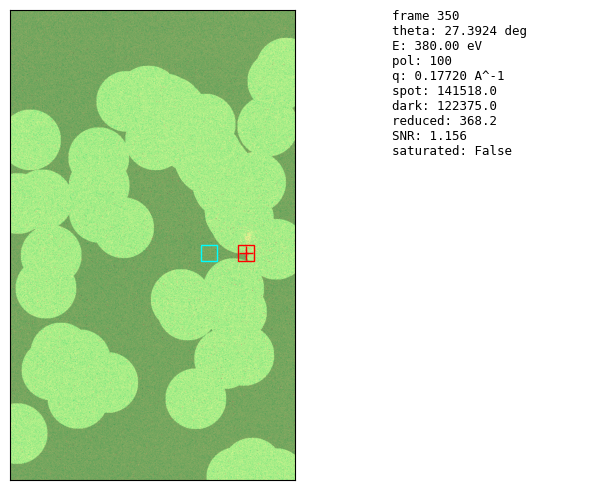

In [21]:
frame_figure(full, 350)

In [19]:
refl = meta.reduce(apply_scale=True)


In [45]:
refl_test = refl[refl['energy']==398.0]

In [13]:
full.data.columns

Index(['fits_index', 'scan', 'energy', 'polarization', 'sam_th', 'det_th',
       'sam_x', 'sam_y', 'sam_z', 'exposure', 'hos', 'slits_vert',
       'slits_horz', 'beam_current', 'i0', 'wavelength', 'q', 'beam_spot',
       'counts_spot', 'counts_dark', 'counts_ratio', 'is_saturated',
       'counts_refl', 'counts_err', 'beam_found', 'beam_snr'],
      dtype='str')

For live cycling with Prev/Next buttons, run this in a **windowed** matplotlib
session (not inline):

#```python
#from pxr_reduce.viewer import FrameBrowser
#FrameBrowser(loader).show()
#```

## 8. Sanity-check the reduced curve (subset)

A quick reduction of the tuning subset. Use `apply_scale=False` to skip stitch
scaling for the fastest look.

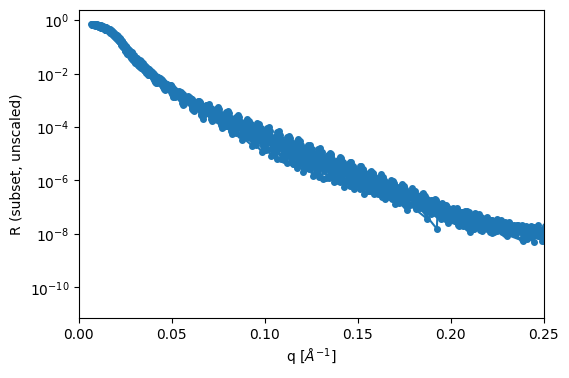

In [36]:
#refl = loader.reduce(apply_scale=False)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r['q'], r['R'], 'o-', ms=4)
ax.set_yscale('log')
ax.set_xlabel(r'q [$\AA^{-1}$]'); ax.set_ylabel('R (subset, unscaled)')
ax.set_xlim(0, 0.25)
plt.show()


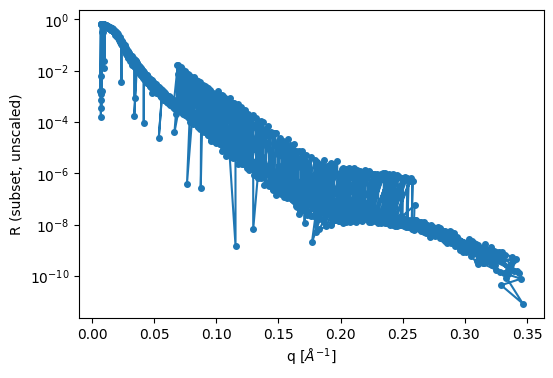

In [47]:
#refl = loader.reduce(apply_scale=False)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r['q'], r['R'], 'o-', ms=4)
ax.set_yscale('log')
ax.set_xlabel(r'q [$\AA^{-1}$]'); ax.set_ylabel('R (subset, unscaled)')
#ax.set_xlim(45, 60)
plt.show()

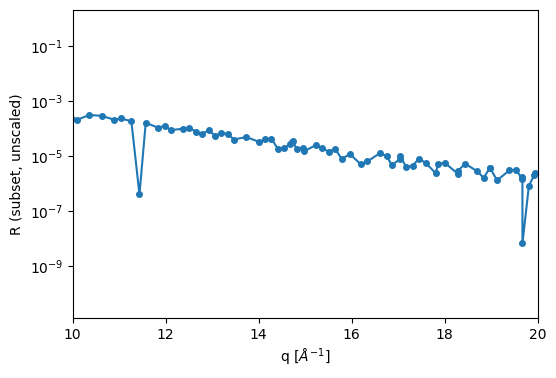

In [68]:

#refl = loader.reduce(apply_scale=False)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r[r['energy']==380.0]['sam_th'], r[r['energy']==380.0]['R'], 'o-', ms=4)
ax.set_yscale('log')
ax.set_xlabel(r'q [$\AA^{-1}$]'); ax.set_ylabel('R (subset, unscaled)')
ax.set_xlim(10, 20)
plt.show()

0       False
1       False
2        True
3       False
4        True
        ...  
1404    False
1405    False
1406    False
1407    False
1408    False
Name: energy, Length: 1409, dtype: bool

In [12]:
r

,sam_th,energy,polarization,scan,q,R,R_err
0,1.0011,380.0,100.0,0.0,0.006729,1.360624e-02,1.647336e-04
1,1.0011,398.0,100.0,1.0,0.007048,1.013982e-02,3.414948e-04
2,1.0011,399.0,100.0,2.0,0.007066,4.648833e-03,3.814210e-04
3,1.0011,400.0,100.0,3.0,0.007083,3.401602e-02,4.534618e-04
4,1.0511,398.0,100.0,1.0,0.007400,1.773323e-03,3.241678e-04
...,...,...,...,...,...,...,...
1957,59.8069,399.0,100.0,2.0,0.349541,1.140442e-10,4.894702e-10
1958,60.0011,380.0,100.0,0.0,0.333551,1.205995e-09,3.906036e-10
1959,60.0011,398.0,100.0,1.0,0.349351,1.443871e-09,4.020176e-10
1960,60.0011,399.0,100.0,2.0,0.350229,8.911038e-10,5.599513e-10


## 9. Save the config and get the CLI command

Once the overlays look right, save the tuned config and run the printed command on
the **full** dataset. `--config` applies every parameter you set above (not just
the ones with dedicated flags).

In [ ]:
config_path = Path("tuned_config.json").resolve()
config.save_json(config_path)
print(f"Saved config -> {config_path}\n")

print("Run on the full dataset with:\n")
print(f'pxr-reduce run "{data_folder}" --config "{config_path}"')
print("\nPreview first (writes nothing):\n")
print(f'pxr-reduce run "{data_folder}" --config "{config_path}" --dry-run -v')

## Notes

- `--config` sets all reduction parameters from the file; `--roi-height` /
  `--roi-width` on the command line still override it for a quick tweak.
- Run-behavior flags are independent of the config: `--quick` (skip scaling),
  `--subsample N`, `--no-plots`, `--dry-run`, `--results-dir`, `-o`.
- Outputs go to `./results` in whatever directory you run the CLI from.